In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Hyper params

In [ ]:
### Path settings
parent_path = "images"
image_path = "image.png"
save_path = "processed2"

### Edge enhancement threshold
th = 100

In [33]:
parent_path = os.path.join(".", parent_path)
image_path = os.path.join(parent_path, image_path)
save_path = os.path.join(parent_path, save_path)
if not os.path.exists(save_path):
    os.mkdir(save_path)

In [34]:
image = Image.open(image_path).convert('L')
image = np.array(image)
print(image.shape)

(1536, 2816)


# Convolution

In [35]:
def conv2d_legacy(image, kernel, stride=1, padding=0):
    image = np.array(image)
    kernel = np.array(kernel)
    
    H, W = image.shape
    KH, KW = kernel.shape
    
    out_H = (H - KH + 2*padding)//stride + 1
    out_W = (W - KW + 2*padding)//stride + 1
    
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
        
    processed_img = np.zeros((out_H, out_W))
    
    for i in range(out_H):
        for j in range(out_W):
            processed_img[i, j] = np.sum(image[i:i+KW*stride, j:j+KH*stride] * kernel)
    
    return processed_img

솔직히 위 코드는 너무 느리다. 벡터화를 진행해야하나... 그정도로 지식이 깊지 않아서 gemini로 만들겠다

In [36]:
def conv2d(image, kernel, stride=1, padding=0):
    image = np.array(image)
    kernel = np.array(kernel)
    
    H, W = image.shape
    KH, KW = kernel.shape
    
    # 1. Padding 적용
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    
    # 패딩 후 크기 업데이트
    H_pad, W_pad = image.shape
    
    # 2. 출력 크기 계산
    out_H = (H_pad - KH) // stride + 1
    out_W = (W_pad - KW) // stride + 1
    
    # 3. Sliding Window 추출 (as_strided 사용)
    # image.strides는 메모리에서 다음 행/열로 가기 위해 건너뛰어야 하는 바이트 수입니다.
    s0, s1 = image.strides
    
    # 윈도우 뷰 생성: (출력_행, 출력_열, 커널_행, 커널_열)
    # strides: (행 이동 시 stride만큼 점프, 열 이동 시 stride만큼 점프, 커널 내 행 이동, 커널 내 열 이동)
    windows = np.lib.stride_tricks.as_strided(
        image, 
        shape=(out_H, out_W, KH, KW), 
        strides=(s0 * stride, s1 * stride, s0, s1),
        writeable=False # 메모리 안전을 위해 뷰 모드로 설정
    )
    
    # 4. 연산: 윈도우와 커널의 요소별 곱의 합
    # 'ij kl, kl -> ij' 연산과 동일 (einsum 사용 시 가독성이 좋음)
    return np.einsum('ijkl,kl->ij', windows, kernel)

## Image Processing Fn

In [37]:
def cmpImg(original, image_stack):
    num_image = image_stack.shape[0] + 1
    
    fig = plt.figure(figsize=(15, 5))
    plt.subplot(1, num_image, 1)
    plt.title("Original")
    plt.axis('off')
    plt.imshow(original, cmap='gray')
    
    for ax in range(num_image-1):
        plt.subplot(1, num_image, ax+2)
        plt.imshow(image_stack[ax], cmap='gray')
        plt.axis('off')
        
    plt.tight_layout()
    return fig

In [38]:
def gaussian_blur(image, kernel_size=5):
    kernel = np.ones([kernel_size, kernel_size])/kernel_size
    return conv2d(image, kernel)

In [39]:
def scaling(image):
    img_max = image.max()
    if img_max == 0:
        return image.astype(np.uint8)
    image = (image / img_max) * 255
    image = image.astype(np.uint8)
    return image

In [40]:
def enhancement(image, th=100):
    return np.where(image > th, 255, 0)

In [41]:
def NMS(sobel, angle):
    r, c = sobel.shape[:2]
    dst = np.zeros((r, c), np.float32)
    for i in range(1, r-1):
        for j in range(1, c-1):
            values = sobel[i-1:i+2, j-1:j+2].flatten()
            first = [3, 0 ,1, 2]
            ii = first[angle[i, j]]
            v1, v2 = values[ii], values[8-ii]
            dst[i, j] = sobel[i, j] if (v1 < sobel[i, j] > v2) else 0
    return dst

In [42]:
def hysteresis(img, max, min):
    r, c = img.shape
    dst = np.zeros((r, c), dtype=np.uint8)
    
    stv = 255
    wkv = 50
    
    sti, stj = np.where(img > max)
    wki, wkj = np.where((img > min) & (img < max))
    
    dst[sti, stj] = stv
    dst[wki, wkj] = wkv
    
    # 연결성 검사
    dx = [-1, -1, 0, 1, 1, 1, 0, -1]
    dy = [0, 1, 1, 1, 0, -1, -1, -1]
    
    stack = list(zip(sti, stj))
    
    while stack:
        x, y = stack.pop()
        
        for k in range(8):
            nx, ny = x + dx[k], y + dy[k]

            if 0 <= nx < r and 0 <= ny < c:
                if dst[nx, ny] == wkv:
                    dst[nx, ny] = stv 
                    stack.append((nx, ny))
    
    dst[dst != stv] = 0
    
    return dst

## Kernels

In [43]:
sobel_X = [[-1, 0, 1], 
           [-2, 0, 2],
           [-1, 0, 1]]

sobel_Y = [[-1, -2, -1], 
           [ 0,  0,  0], 
           [ 1,  2,  1]]

prewitt_X = [[-1, 0, 1], 
             [-1, 0, 1], 
             [-1, 0, 1]]

prewitt_Y = [[-1, -1, -1], 
             [ 0,  0,  0], 
             [ 1,  1,  1]]


laplacian = [[0,  1, 0], 
             [1, -4, 1], 
             [0,  1, 0]]

laplacian_expanded = [[1,  1, 1], 
                      [1, -8, 1], 
                      [1,  1, 1]]

## Edge Detection

### Sobel

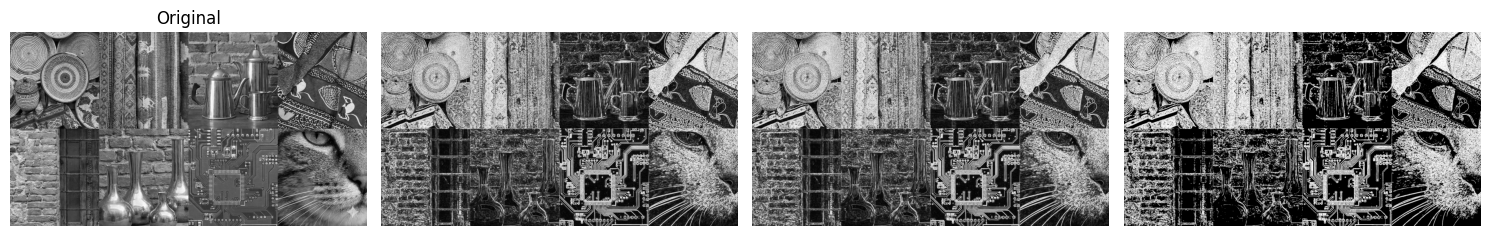

In [44]:
vertical = conv2d(image, sobel_X).astype(np.float32)
horizontal = conv2d(image, sobel_Y).astype(np.float32)

mag_img = np.sqrt(vertical**2+horizontal**2)
mag_img = np.clip(mag_img, 0, 255).astype(np.uint8)
scaled_img = scaling(mag_img)
enhanced_img = scaling(enhancement(mag_img, th))

img_stack = np.stack([mag_img, scaled_img, enhanced_img])
fig = cmpImg(image, img_stack)
fig.savefig(os.path.join(save_path, "sobel.png"), dpi=300, bbox_inches='tight')

### Prewitt

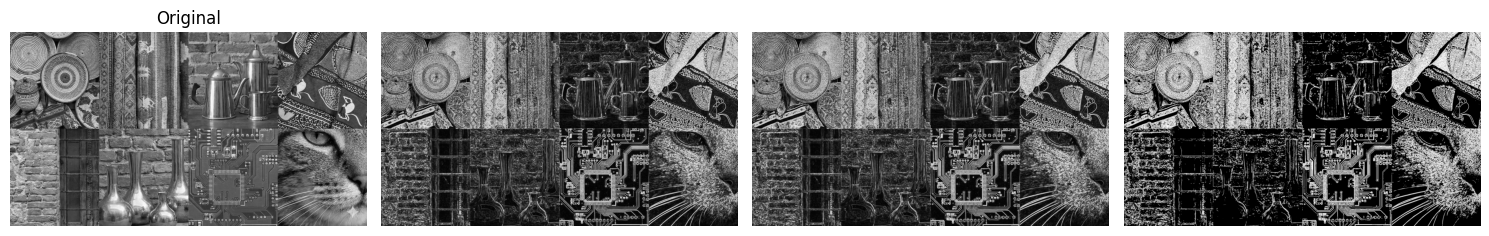

In [45]:
vertical = conv2d(image, prewitt_X).astype(np.float32)
horizontal = conv2d(image, prewitt_Y).astype(np.float32)

mag_img = np.sqrt(vertical**2+horizontal**2)
mag_img = np.clip(mag_img, 0, 255).astype(np.uint8)
scaled_img = scaling(mag_img)
enhanced_img = scaling(enhancement(mag_img, th))

img_stack = np.stack([mag_img, scaled_img, enhanced_img])
fig = cmpImg(image, img_stack)
fig.savefig(os.path.join(save_path, "prewitt.png"), dpi=300, bbox_inches='tight')

### laplacian

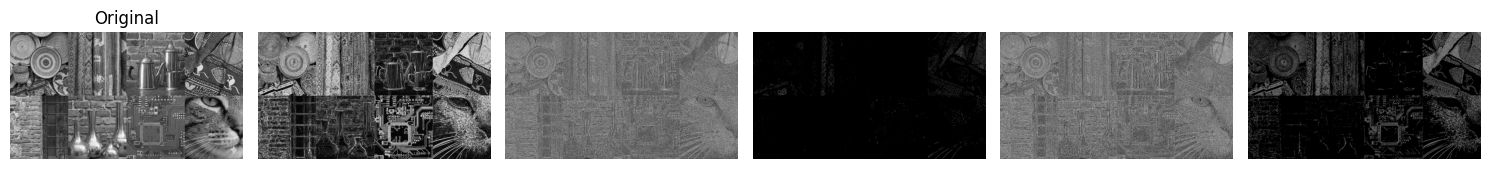

In [46]:
lap = conv2d(image, laplacian).astype(np.float32)
lap_exp = conv2d(image, laplacian_expanded).astype(np.float32)

scaled_img1 = scaling(lap)
enhanced_img1 = scaling(enhancement(lap, th))
scaled_img2 = scaling(lap_exp)
enhanced_img2 = scaling(enhancement(lap_exp, th))

img_stack = np.stack([mag_img, scaled_img1, enhanced_img1, scaled_img2, enhanced_img2])
fig = cmpImg(image, img_stack)
fig.savefig(os.path.join(save_path, "laplacian.png"), dpi=300, bbox_inches='tight')

### Canny

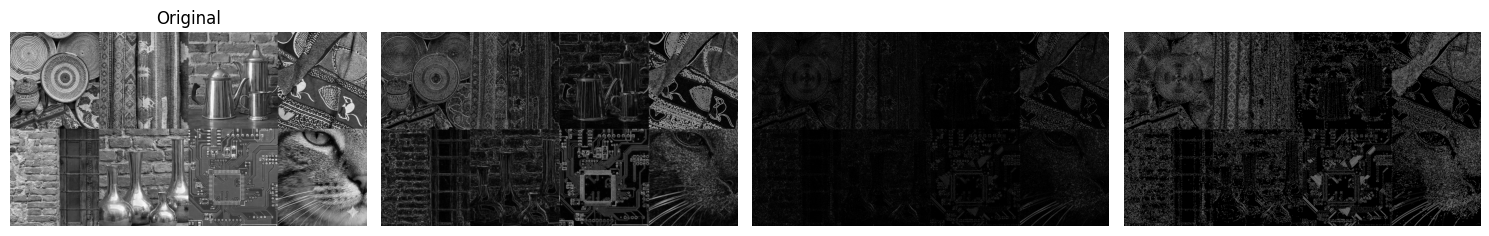

In [47]:
blur_img = gaussian_blur(image)

vertical = conv2d(blur_img, sobel_X).astype(np.float32)
horizontal = conv2d(blur_img, sobel_Y).astype(np.float32)
mag_img = np.sqrt(vertical**2+horizontal**2)

theta = np.arctan2(vertical, horizontal)
angle = theta * 180. / np.pi

angle[angle < 0] += 180
angle_idx = np.zeros(angle.shape, dtype=np.int32)
angle_idx[((angle >= 0) & (angle < 22.5)) | ((angle >= 157.5) & (angle <= 180))] = 0
angle_idx[(angle >= 22.5) & (angle < 67.5)] = 1
angle_idx[(angle >= 67.5) & (angle < 112.5)] = 2
angle_idx[(angle >= 112.5) & (angle < 157.5)] = 3

nms_img = NMS(mag_img, angle_idx)

v = np.median(nms_img[nms_img > 0])
sigma = 0.33
lower = int(max(0, (1.0-sigma)*v))
upper = int(min(255, (1.0+sigma)*v))

hys_img = hysteresis(nms_img, lower, upper)

img_stack = np.stack([mag_img, nms_img, hys_img])
fig = cmpImg(image, img_stack)
fig.savefig(os.path.join(save_path, "canny.png"), dpi=300, bbox_inches='tight')